In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load scaled data (used for clustering)
df_scaled = pd.read_csv("../Data/Preprocessed/Preprocessed.csv")
print("Scaled data shape:", df_scaled.shape)

# Load original data (contains raw features and true_segment)
df_original = pd.read_excel("../Data/Raw/telecom_customer_segmentation.xlsx", engine='openpyxl')
print("Original data shape:", df_original.shape)

Scaled data shape: (5000, 21)
Original data shape: (5000, 20)


In [2]:
# Train KMeans with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df_original['cluster'] = kmeans.fit_predict(df_scaled)

# Check cluster distribution
print("Cluster sizes:")
print(df_original['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     404
1    1050
2    1291
3     497
4    1758
Name: count, dtype: int64


In [3]:
# Business labels (to be refined after analysing summary)
cluster_labels = {
    0: 'At-Risk Churners',
    1: 'Heavy Users',
    2: 'Low Value Passive',
    3: 'High Revenue VIPs',
    4: 'Moderate Users'
}

df_original['segment_label'] = df_original['cluster'].map(cluster_labels)
print("\nSegment label mapping applied.")
print(df_original[['cluster', 'segment_label']].drop_duplicates().sort_values('cluster'))


Segment label mapping applied.
    cluster      segment_label
11        0   At-Risk Churners
4         1        Heavy Users
1         2  Low Value Passive
7         3  High Revenue VIPs
0         4     Moderate Users


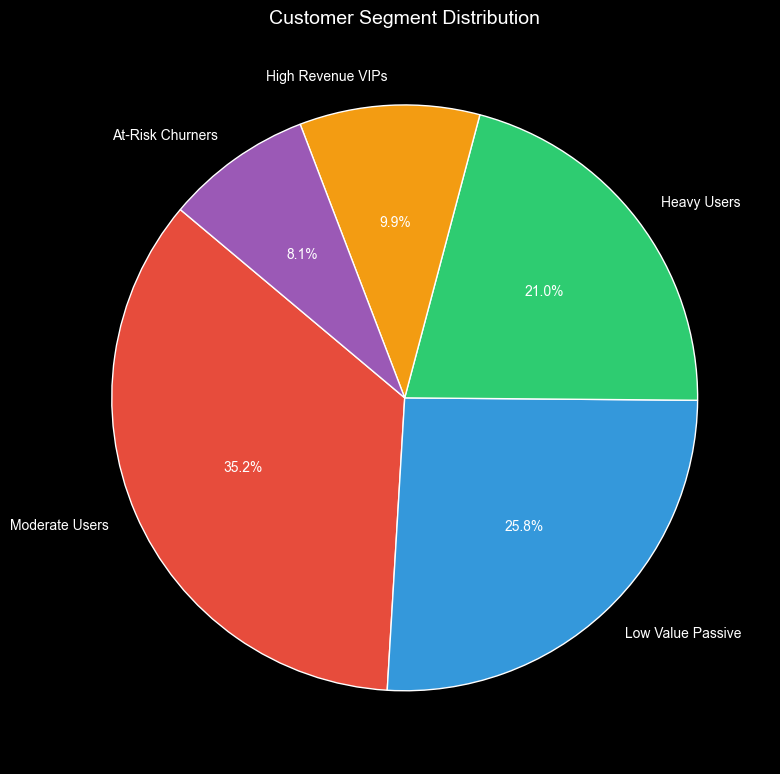

In [4]:
# Colours for the five segments
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
counts = df_original['segment_label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Customer Segment Distribution', fontsize=14)
plt.tight_layout()
plt.show()

Feature averages by segment:
                   monthly_revenue_usd  total_call_minutes  data_usage_gb  \
segment_label                                                               
At-Risk Churners                 32.99              148.48           4.93   
Heavy Users                      91.12              805.16          24.60   
High Revenue VIPs               212.97              590.16          19.65   
Low Value Passive                20.53               87.23           2.14   
Moderate Users                   44.33              344.66           9.90   

                   tenure_months  support_tickets_6mo  logins_per_month  
segment_label                                                            
At-Risk Churners            9.11                 4.96              3.92  
Heavy Users                70.73                 1.04             24.69  
High Revenue VIPs          88.39                 1.48             22.02  
Low Value Passive          11.81                 0.09        

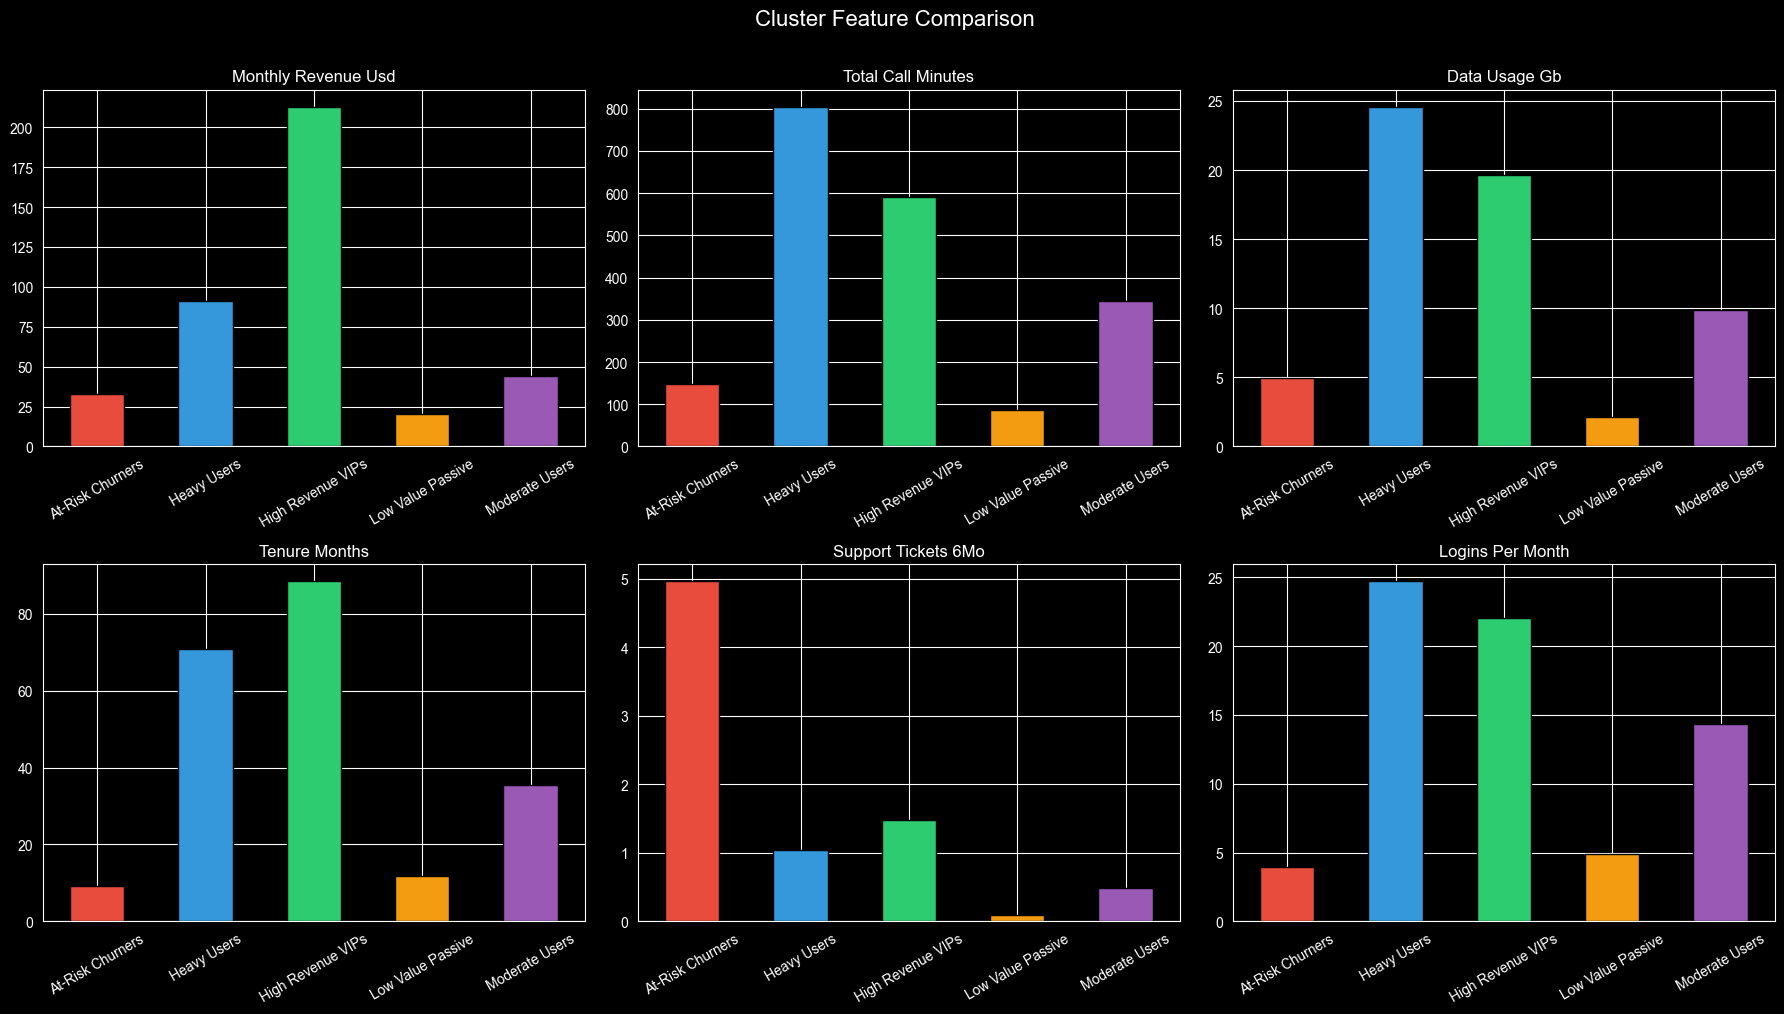

In [5]:
metrics = ['monthly_revenue_usd', 'total_call_minutes', 'data_usage_gb',
           'tenure_months', 'support_tickets_6mo', 'logins_per_month']

# Compute mean per segment
summary = df_original.groupby('segment_label')[metrics].mean().round(2)
print("Feature averages by segment:")
print(summary)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(metrics):
    summary[col].plot(kind='bar', ax=axes[i], color=colors, edgecolor='black')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Cluster Feature Comparison', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

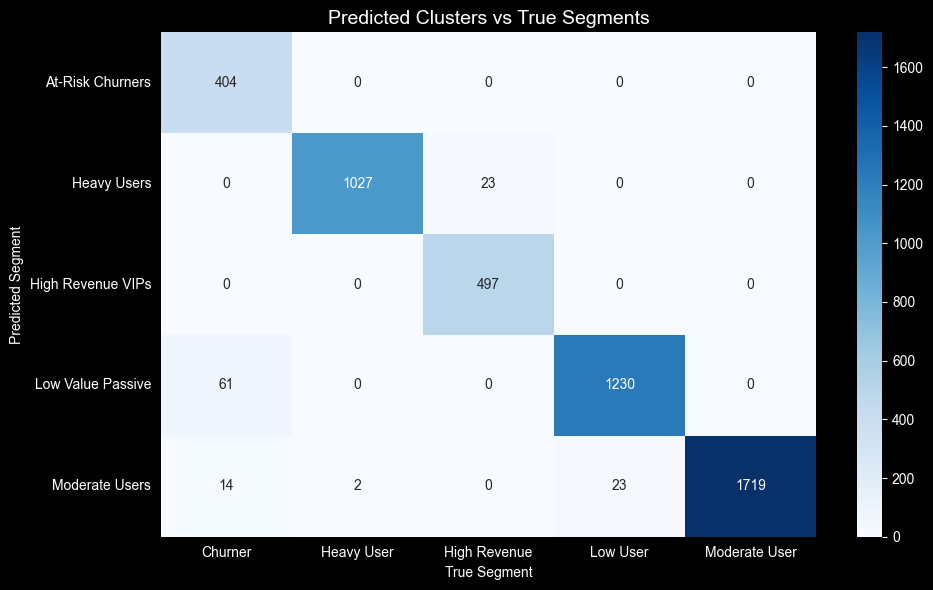

In [6]:
# Cross-tabulation
ct = pd.crosstab(df_original['segment_label'], df_original['true_segment'])

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Predicted Clusters vs True Segments', fontsize=14)
plt.xlabel('True Segment')
plt.ylabel('Predicted Segment')
plt.tight_layout()
plt.show()